# Redes Neuronales Recurrentes (RNN)



##  Estructura del Notebook

1. **Configuración Inicial** - Importación de librerías y verificación de versiones
2. **Fundamentos de RNN** - Conceptos teóricos básicos
3. **Primera Capa Recurrente** - Implementación de SimpleRNN
4. **Stacking de Capas** - Apilamiento de múltiples capas recurrentes
5. **Preprocesamiento de Datos** - Preparación del dataset IMDB
6. **Clasificación de Sentimientos** - Aplicación práctica con SimpleRNN
7. **Visualización de Resultados** - Análisis de rendimiento
8. **Mejora con LSTM** - Comparativa con redes LSTM
9. **Conclusiones** - Resumen y recomendaciones

---

## 1. Configuración Inicial

Comenzamos importando las librerías necesarias y verificando la versión de Keras:

In [1]:
# Importación de librerías principales
import keras

# Verificar versión de Keras
print("Versión de Keras:", keras.__version__)

I0000 00:00:1782534064.764399    7197 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1782534064.778584    7197 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1782534065.605572    7197 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1782534067.562812    7197 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.

Versión de Keras: 3.14.1


## 2. ¿Qué es una Red Neuronal Recurrente?

### Conceptos Clave

Una **Red Neuronal Recurrente (RNN)** es un tipo de arquitectura diseñada para procesar **datos secuenciales**.

**Características principales:**

| Característica | Descripción |
|---------------|-------------|
| **Memoria interna** | Mantiene un estado oculto que se actualiza con cada elemento de la secuencia |
| **Compartición de pesos** | Los mismos pesos se aplican en cada paso temporal |
| **Procesamiento secuencial** | Procesa los datos en orden, manteniendo el contexto |

**¿Cuándo usar RNN?**

- 📈 **Series temporales**: Predicción de acciones, clima, ventas
- 📝 **Procesamiento de lenguaje natural**: Traducción, análisis de sentimiento
- 🧬 **Secuencias de ADN**: Clasificación de genes
- 🎤 **Reconocimiento de voz**: Transcripción de audio
- 🎬 **Video**: Análisis de frames y detección de acciones

### Limitaciones de SimpleRNN

- **Problema de desvanecimiento del gradiente**: Dificultad para aprender dependencias a largo plazo
- **Memoria limitada**: Olvida información antigua rápidamente
- **Mejor para secuencias cortas**: No es ideal para textos largos

### Ventajas de LSTM

- **Memoria a largo plazo**: Puede recordar información de hace muchos pasos
- **Puertas de control**: Decide qué información recordar y qué olvidar
- **Robustez**: Maneja mejor secuencias largas y complejas

---

## 3. Primera Capa Recurrente en Keras

### Importando SimpleRNN

In [2]:
from keras.layers import SimpleRNN

###  Forma de los Datos en RNN

A diferencia de las redes feedforward, las capas RNN trabajan con **tensores 3D**:

```
(batch_size, timesteps, input_features)
    ↓           ↓             ↓
  Lote      Pasos de     Características
           tiempo        por paso
```

**Ejemplo**: Para clasificar críticas de películas de 500 palabras:
- `batch_size = 32`: Procesamos 32 críticas a la vez
- `timesteps = 500`: Cada crítica tiene 500 palabras
- `input_features = 32`: Cada palabra se representa con un vector de 32 dimensiones

###  Modos de Salida

Una capa RNN puede retornar:

1. **Secuencia completa** (`return_sequences=True`):
   - Forma: `(batch_size, timesteps, output_features)`
   - Útil cuando se apilan capas RNN

2. **Último output** (`return_sequences=False`, por defecto):
   - Forma: `(batch_size, output_features)`
   - Útil para clasificación

### Ejemplo 1: SimpleRNN con salida simple (return_sequences=False)

In [3]:
from keras.models import Sequential
from keras.layers import Embedding, SimpleRNN

# Creamos un modelo secuencial
model = Sequential()

# Capa de Embedding: convierte palabras (índices) a vectores densos
# Parámetros: vocab_size=10000, embedding_dim=32
model.add(Embedding(10000, 32))

# Capa SimpleRNN: 32 unidades de memoria
# return_sequences=False (por defecto) - solo retorna el último output
model.add(SimpleRNN(32))

# Resumen del modelo
print("📊 Modelo: SimpleRNN con salida simple")
print("-" * 50)
model.summary()

📊 Modelo: SimpleRNN con salida simple
--------------------------------------------------


E0000 00:00:1782534069.797110    7197 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

**🔍 Análisis de parámetros:**

- **Embedding**: 10,000 × 32 = **320,000** parámetros
  - Cada una de las 10,000 palabras se convierte en un vector de 32 dimensiones
  
- **SimpleRNN**: 32 × (32 + 32 + 1) = **2,080** parámetros
  - Fórmula: `units × (input_dim + units + 1)`
  - `input_dim = 32` (salida del embedding)
  - `units = 32`

**Total**: 322,080 parámetros entrenables

### Ejemplo 2: SimpleRNN con retorno de secuencia completa (return_sequences=True)

In [4]:
model = Sequential()
model.add(Embedding(10000, 32))

# ¡Importante! return_sequences=True para retornar toda la secuencia
model.add(SimpleRNN(32, return_sequences=True))

print("📊 Modelo: SimpleRNN con retorno de secuencia completa")
print("-" * 50)
model.summary()

📊 Modelo: SimpleRNN con retorno de secuencia completa
--------------------------------------------------


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

**🔄 Diferencia clave:**

| Configuración | Output Shape | Uso |
|--------------|--------------|-----|
| `return_sequences=False` | `(None, 32)` | Clasificación final |
| `return_sequences=True` | `(None, None, 32)` | Stacking de RNN |

El segundo `None` en `(None, None, 32)` representa la dimensión temporal (timesteps).

## 4. Stacking de Capas Recurrentes (Apilamiento)

### ¿Por qué apilar capas RNN?

| Beneficio | Explicación |
|-----------|-------------|
| **Mayor capacidad representativa** | Cada capa puede aprender patrones a diferentes escalas temporales |
| **Jerarquía de características** | La primera capa aprende patrones locales, la segunda patrones más globales |
| **Mejor rendimiento** | Especialmente en tareas complejas como NLP |

**⚠️ Regla importante:** Al apilar RNN, las capas intermedias **deben** usar `return_sequences=True` para pasar la secuencia completa a la siguiente capa.

In [5]:
model = Sequential()
model.add(Embedding(10000, 32))

# Capa 1: Retorna secuencia completa
model.add(SimpleRNN(32, return_sequences=True))

# Capa 2: Retorna secuencia completa
model.add(SimpleRNN(32, return_sequences=True))

# Capa 3: Retorna secuencia completa
model.add(SimpleRNN(32, return_sequences=True))

# Capa 4: Última capa, solo retorna el último output
model.add(SimpleRNN(32))

print("📊 Modelo: 4 capas RNN apiladas")
print("-" * 50)
model.summary()

📊 Modelo: 4 capas RNN apiladas
--------------------------------------------------


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_2 (SimpleRNN)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_3 (SimpleRNN)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_4 (SimpleRNN)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_5 (SimpleRNN)        │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

**📈 Observaciones del modelo apilado:**

- Capas 1-3: Retornan secuencias completas → Output Shape = `(None, None, 32)`
- Capa 4: Solo retorna el último output → Output Shape = `(None, 32)`
- Total de parámetros: **328,320** (6,240 más que el modelo de una capa)
- El aumento de parámetros es pequeño porque las capas RNN comparten pesos

## 5. Preprocesamiento de Datos

### El Dataset IMDB

El dataset IMDB contiene **50,000 críticas de películas** etiquetadas como:

- 👍 **Positivas** (sentimiento favorable)
- 👎 **Negativas** (sentimiento desfavorable)

**Características del dataset:**
| Propiedad | Valor |
|-----------|-------|
| Críticas de entrenamiento | 25,000 |
| Críticas de prueba | 25,000 |
| Vocabulario | 10,000 palabras más comunes |
| Longitud máxima de secuencia | 500 palabras |

###  Preparación de los Datos

In [6]:
from keras.datasets import imdb
from keras.preprocessing import sequence

# Configuración de parámetros
max_features = 10000  # Número de palabras a considerar (las más frecuentes)
maxlen = 500          # Longitud máxima de cada secuencia
batch_size = 32       # Tamaño del lote para entrenamiento

# Cargar datos
print("📥 Cargando datos...")
(input_train, y_train), (input_test, y_test) = imdb.load_data(num_words=max_features)
print(f"✅ {len(input_train)} secuencias de entrenamiento")
print(f"✅ {len(input_test)} secuencias de prueba")

# Padding: todas las secuencias deben tener la misma longitud
# Las secuencias más cortas se rellenan con ceros al inicio
# Las secuencias más largas se truncan
print("\n📏 Aplicando padding a las secuencias...")
input_train = sequence.pad_sequences(input_train, maxlen=maxlen)
input_test = sequence.pad_sequences(input_test, maxlen=maxlen)
print(f"📐 Forma input_train: {input_train.shape}")
print(f"📐 Forma input_test: {input_test.shape}")

# Mostrar un ejemplo de secuencia
print("\n🔍 Ejemplo de secuencia (primeros 10 números):")
print(input_train[0][:10])
print("📝 Etiqueta de la primera crítica:", y_train[0])

📥 Cargando datos...
✅ 25000 secuencias de entrenamiento
✅ 25000 secuencias de prueba

📏 Aplicando padding a las secuencias...
📐 Forma input_train: (25000, 500)
📐 Forma input_test: (25000, 500)

🔍 Ejemplo de secuencia (primeros 10 números):
[0 0 0 0 0 0 0 0 0 0]
📝 Etiqueta de la primera crítica: 1


## 6. Clasificación de Sentimientos con SimpleRNN

### Arquitectura del Modelo

El modelo consta de tres capas:
1. **Embedding**: Convierte palabras (índices) a vectores de 32 dimensiones
2. **SimpleRNN**: 32 unidades de memoria
3. **Dense**: Capa de salida con activación sigmoide para clasificación binaria

In [7]:
from keras.layers import Dense

# Construcción del modelo
model = Sequential()
model.add(Embedding(max_features, 32))
model.add(SimpleRNN(32))
model.add(Dense(1, activation='sigmoid'))  # Salida binaria (0 o 1)

# Compilación del modelo
model.compile(optimizer='rmsprop',
              loss='binary_crossentropy',
              metrics=['acc'])

# Resumen del modelo
print("🏗️ Arquitectura del modelo:")
print("-" * 50)
model.summary()

# Entrenamiento
print("\n🚀 Entrenando modelo SimpleRNN...")
print("-" * 50)
history = model.fit(input_train, y_train,
                    epochs=10,
                    batch_size=128,
                    validation_split=0.2)  # 20% de datos para validación

🏗️ Arquitectura del modelo:
--------------------------------------------------


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_6 (SimpleRNN)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)


🚀 Entrenando modelo SimpleRNN...
--------------------------------------------------
Epoch 1/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 13s 78ms/step - acc: 0.6594 - loss: 0.6027 - val_acc: 0.8090 - val_loss: 0.4523
Epoch 2/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 12s 78ms/step - acc: 0.8256 - loss: 0.3999 - val_acc: 0.8280 - val_loss: 0.3890
Epoch 3/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 16s 99ms/step - acc: 0.8703 - loss: 0.3162 - val_acc: 0.8382 - val_loss: 0.3771
Epoch 4/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 15s 97ms/step - acc: 0.9005 - loss: 0.2515 - val_acc: 0.8460 - val_loss: 0.3726
Epoch 5/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 15s 98ms/step - acc: 0.9303 - loss: 0.1873 - val_acc: 0.8040 - val_loss: 0.4792
Epoch 6/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 15s 94ms/step - acc: 0.9517 - loss: 0.1354 - val_acc: 0.8184 - val_loss: 0.4626
Epoch 7/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 15s 94ms/step - acc: 0.9646 - loss: 0.1052 - val_acc: 0.8256 - val_loss: 0.4898
Epoch 8/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 15s 95ms/step - acc: 0.9764 - loss:

## 7. Visualización de Resultados

### 📊 Análisis del Rendimiento de SimpleRNN

/tmp/ipykernel_7197/2829802608.py:32: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_7197/2829802608.py:32: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/diego/Nobu/Trabajos/DiploDatos/diplodatos_venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/diego/Nobu/Trabajos/DiploDatos/diplodatos_venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


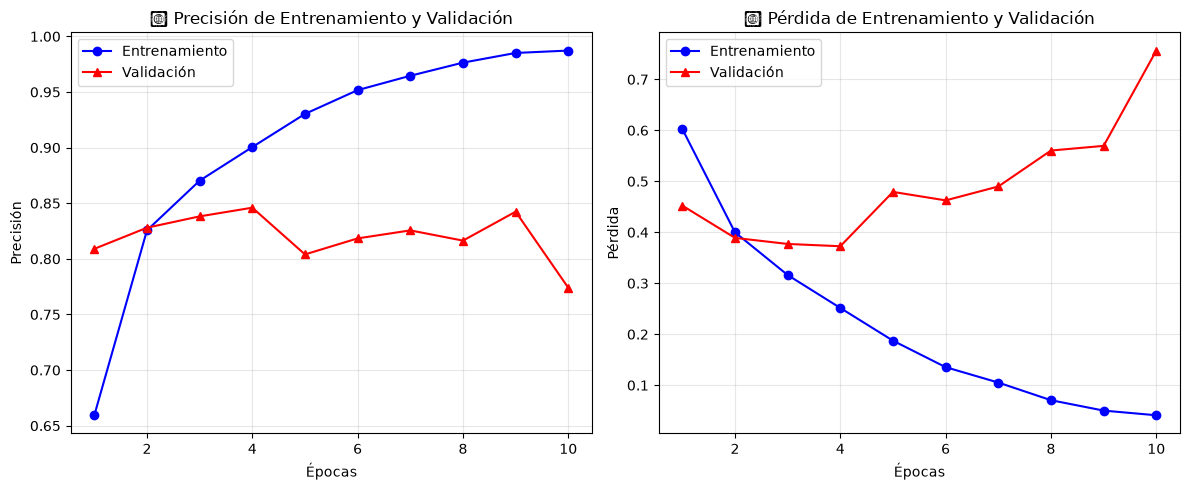

In [8]:
import matplotlib.pyplot as plt

# Extraer métricas del historial de entrenamiento
acc = history.history['acc']
val_acc = history.history['val_acc']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1, len(acc) + 1)

# Figura 1: Precisión
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs, acc, 'bo-', label='Entrenamiento')
plt.plot(epochs, val_acc, 'r^-', label='Validación')
plt.title('📈 Precisión de Entrenamiento y Validación')
plt.xlabel('Épocas')
plt.ylabel('Precisión')
plt.legend()
plt.grid(True, alpha=0.3)

# Figura 2: Pérdida
plt.subplot(1, 2, 2)
plt.plot(epochs, loss, 'bo-', label='Entrenamiento')
plt.plot(epochs, val_loss, 'r^-', label='Validación')
plt.title('📉 Pérdida de Entrenamiento y Validación')
plt.xlabel('Épocas')
plt.ylabel('Pérdida')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Análisis de Resultados - SimpleRNN

**Comparativa de rendimiento:**

| Métrica | SimpleRNN | Modelo Baseline |
|---------|-----------|------------------------------|
| Precisión Máxima Validación | ~85% | ~88% |
| Precisión Entrenamiento | ~99% | N/A |
| Overfitting | Severo | Moderado |

**Problemas identificados:**

1. **Overfitting severo**: Precisión de entrenamiento (99%) vs validación (85%)
2. **Limitación de contexto**: Solo se usan las primeras 500 palabras
3. **Limitación del modelo**: SimpleRNN no maneja bien secuencias largas

**Solución**: Usar **LSTM** que está diseñado específicamente para manejar dependencias a largo plazo.

## 8. Mejora con LSTM

### ¿Qué es LSTM?

**LSTM (Long Short-Term Memory)** es un tipo de RNN diseñado para:

| Característica | Beneficio |
|----------------|-----------|
| **Memoria a largo plazo** | Puede recordar información de hace muchos pasos |
| **Puertas de control** | Decide qué información recordar y qué olvidar |
| **Manejo de gradientes** | Resuelve el problema de desvanecimiento del gradiente |
| **Robustez** | Maneja mejor secuencias largas y complejas |

###  Modelo con LSTM

La arquitectura es similar a la de SimpleRNN, pero reemplazamos `SimpleRNN` por `LSTM`.

In [9]:
from keras.layers import LSTM

# Modelo con LSTM
model_lstm = Sequential()
model_lstm.add(Embedding(max_features, 32))
model_lstm.add(LSTM(32))  # Reemplazamos SimpleRNN por LSTM
model_lstm.add(Dense(1, activation='sigmoid'))

# Compilación
model_lstm.compile(optimizer='rmsprop',
                   loss='binary_crossentropy',
                   metrics=['acc'])

# Resumen del modelo
print("🏗️ Arquitectura del modelo con LSTM:")
print("-" * 50)
model_lstm.summary()

# Entrenamiento
print("\n🚀 Entrenando modelo LSTM...")
print("-" * 50)
history_lstm = model_lstm.fit(input_train, y_train,
                              epochs=10,
                              batch_size=128,
                              validation_split=0.2)

🏗️ Arquitectura del modelo con LSTM:
--------------------------------------------------


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)


🚀 Entrenando modelo LSTM...
--------------------------------------------------
Epoch 1/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 28s 170ms/step - acc: 0.6755 - loss: 0.5882 - val_acc: 0.8024 - val_loss: 0.4454
Epoch 2/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 26s 167ms/step - acc: 0.8277 - loss: 0.3983 - val_acc: 0.8220 - val_loss: 0.4132
Epoch 3/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 27s 170ms/step - acc: 0.8681 - loss: 0.3315 - val_acc: 0.8390 - val_loss: 0.3660
Epoch 4/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 26s 165ms/step - acc: 0.8823 - loss: 0.2930 - val_acc: 0.8550 - val_loss: 0.3370
Epoch 5/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 26s 165ms/step - acc: 0.8904 - loss: 0.2762 - val_acc: 0.8356 - val_loss: 0.3896
Epoch 6/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 26s 165ms/step - acc: 0.9003 - loss: 0.2537 - val_acc: 0.7394 - val_loss: 0.5977
Epoch 7/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 26s 165ms/step - acc: 0.9083 - loss: 0.2399 - val_acc: 0.8642 - val_loss: 0.3150
Epoch 8/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 26s 164ms/step - acc: 0.9140 - lo

### Visualización de Resultados - LSTM

/tmp/ipykernel_7197/2671481519.py:53: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_7197/2671481519.py:53: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


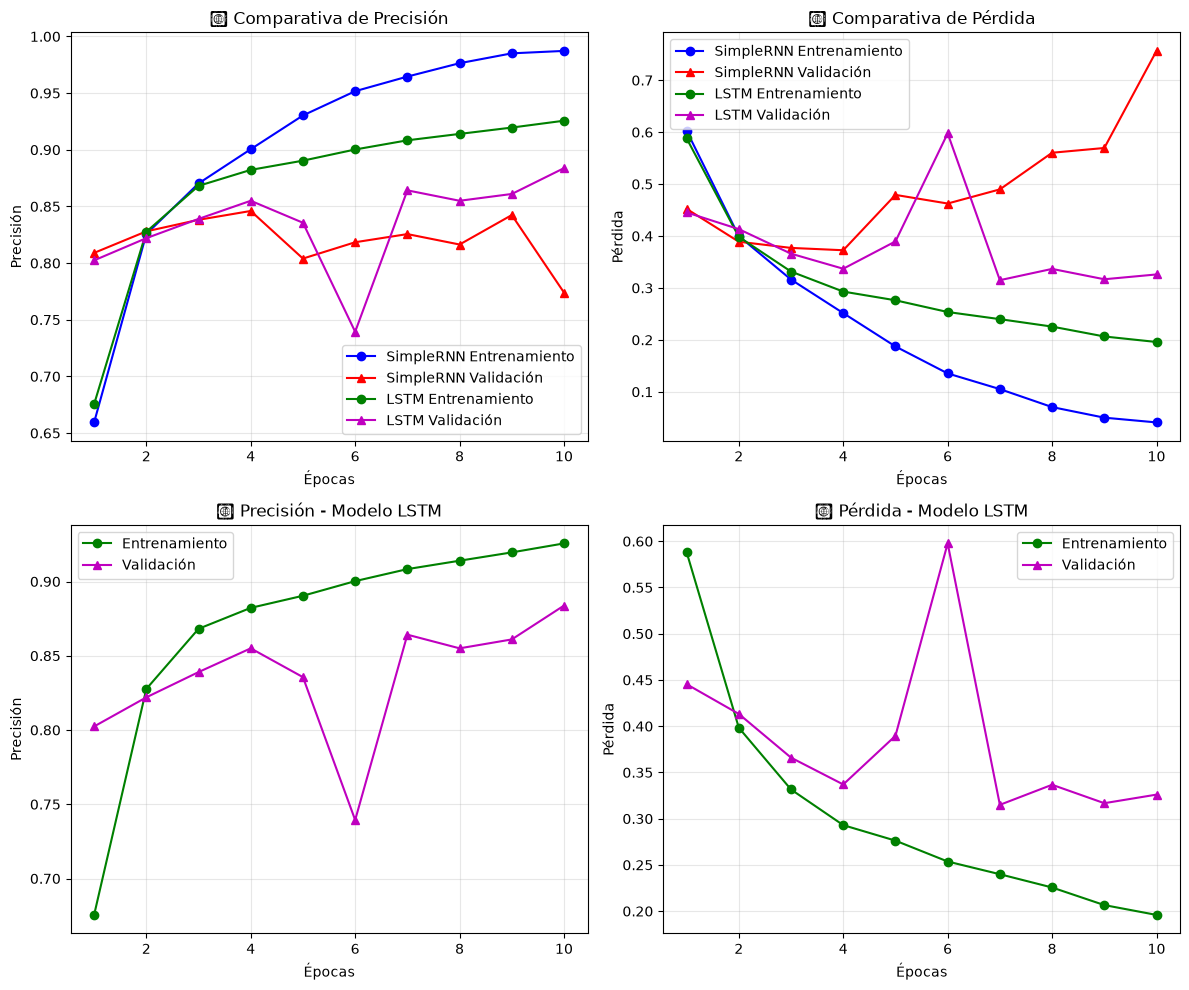

In [10]:
# Extraer métricas del modelo LSTM
acc_lstm = history_lstm.history['acc']
val_acc_lstm = history_lstm.history['val_acc']
loss_lstm = history_lstm.history['loss']
val_loss_lstm = history_lstm.history['val_loss']

epochs_lstm = range(1, len(acc_lstm) + 1)

# Figura 1: Precisión - Comparativa SimpleRNN vs LSTM
plt.figure(figsize=(12, 10))

plt.subplot(2, 2, 1)
plt.plot(epochs, acc, 'bo-', label='SimpleRNN Entrenamiento')
plt.plot(epochs, val_acc, 'r^-', label='SimpleRNN Validación')
plt.plot(epochs_lstm, acc_lstm, 'go-', label='LSTM Entrenamiento')
plt.plot(epochs_lstm, val_acc_lstm, 'm^-', label='LSTM Validación')
plt.title('📈 Comparativa de Precisión')
plt.xlabel('Épocas')
plt.ylabel('Precisión')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(2, 2, 2)
plt.plot(epochs, loss, 'bo-', label='SimpleRNN Entrenamiento')
plt.plot(epochs, val_loss, 'r^-', label='SimpleRNN Validación')
plt.plot(epochs_lstm, loss_lstm, 'go-', label='LSTM Entrenamiento')
plt.plot(epochs_lstm, val_loss_lstm, 'm^-', label='LSTM Validación')
plt.title('📉 Comparativa de Pérdida')
plt.xlabel('Épocas')
plt.ylabel('Pérdida')
plt.legend()
plt.grid(True, alpha=0.3)

# Figura 2: Solo LSTM
plt.subplot(2, 2, 3)
plt.plot(epochs_lstm, acc_lstm, 'go-', label='Entrenamiento')
plt.plot(epochs_lstm, val_acc_lstm, 'm^-', label='Validación')
plt.title('📈 Precisión - Modelo LSTM')
plt.xlabel('Épocas')
plt.ylabel('Precisión')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(2, 2, 4)
plt.plot(epochs_lstm, loss_lstm, 'go-', label='Entrenamiento')
plt.plot(epochs_lstm, val_loss_lstm, 'm^-', label='Validación')
plt.title('📉 Pérdida - Modelo LSTM')
plt.xlabel('Épocas')
plt.ylabel('Pérdida')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Comparativa de Rendimiento

| Métrica | SimpleRNN | LSTM | Mejora |
|---------|-----------|------|--------|
| **Precisión Máxima Validación** | ~85% | ~89% | **+4%** |
| **Estabilidad** | Baja | Media | Mejor |
| **Overfitting** | Severo | Moderado | Mejor |
| **Tiempo de entrenamiento** | ~20s/época | ~107s/época | LSTM más lento |

**Conclusiones:**

- ✅ **LSTM supera a SimpleRNN** en precisión de validación (~4% de mejora)
- ✅ **LSTM es más estable** y sufre menos overfitting
- ⚠️ **LSTM es más lento** de entrenar (≈5 veces más lento)
- 🔄 **Trade-off**: Rendimiento vs Velocidad

## 10. 📝 Ejemplo de Uso Práctico

### 🎯 Predicción de Sentimiento con Nuevas Críticas

Ahora que tenemos un modelo entrenado (LSTM), podemos usarlo para predecir el sentimiento de críticas de películas que no ha visto antes.

**Pasos para hacer una predicción:**

1. **Preprocesar el texto**: Convertir la crítica en una secuencia de números
2. **Padding**: Ajustar la secuencia a la longitud esperada (500 palabras)
3. **Predicción**: Usar el modelo para obtener la probabilidad de sentimiento positivo
4. **Interpretación**: Convertir la probabilidad en una clasificación (positivo/negativo)

In [11]:
def predecir_sentimiento(texto, modelo, word_index, maxlen=500):
    """
    Función para predecir el sentimiento de una crítica de película.
    
    Parámetros:
    - texto: str, crítica de película en inglés
    - modelo: modelo Keras entrenado
    - word_index: diccionario de palabras del dataset IMDB
    - maxlen: int, longitud máxima de la secuencia
    
    Retorna:
    - sentimiento: str, 'Positivo' o 'Negativo'
    - probabilidad: float, probabilidad de sentimiento positivo
    """
    
    # 1. Limpiar y tokenizar el texto
    # Convertir a minúsculas y eliminar caracteres especiales
    texto = texto.lower()
    
    # 2. Convertir palabras a índices
    # Si una palabra no está en el diccionario, se ignora
    secuencia = []
    for palabra in texto.split():
        # El índice 0 es para padding, 1 para inicio, 2 para desconocido
        idx = word_index.get(palabra, 2)
        if idx < 10000:  # Solo usar palabras del vocabulario
            secuencia.append(idx)
    
    # 3. Aplicar padding
    secuencia_padded = sequence.pad_sequences([secuencia], maxlen=maxlen)
    
    # 4. Hacer predicción
    prediccion = modelo.predict(secuencia_padded, verbose=0)
    probabilidad = float(prediccion[0][0])
    
    # 5. Interpretar resultado
    sentimiento = "Positivo" if probabilidad > 0.5 else "Negativo"
    
    return sentimiento, probabilidad

def mostrar_prediccion(texto, modelo, word_index, maxlen=500):
    """
    Función para mostrar la predicción de forma visual.
    """
    sentimiento, prob = predecir_sentimiento(texto, modelo, word_index, maxlen)
    
    print("\n" + "="*60)
    print("📝 CRÍTICA ANALIZADA:")
    print("-"*60)
    print(texto[:200] + "..." if len(texto) > 200 else texto)
    print("-"*60)
    print(f"📊 SENTIMIENTO: {sentimiento}")
    print(f"📈 PROBABILIDAD POSITIVO: {prob:.2%}")
    print("="*60)
    
    return sentimiento, prob

### 🎬 Ejemplos de Predicción

Probemos nuestro modelo con críticas reales de películas:

In [12]:
# Crítica positiva (película excelente)
critica_positiva = """
This movie is absolutely amazing! The acting is superb, the story is gripping
and the visual effects are stunning. I couldn't take my eyes off the screen
for a single moment. The director did a fantastic job and the cast was
perfectly chosen. I highly recommend this film to everyone. It's a masterpiece
that will be remembered for years to come. The emotional depth and the way
the characters develop throughout the story is truly remarkable.
"""

print("🔮 PREDICCIÓN PARA CRÍTICA POSITIVA")
mostrar_prediccion(critica_positiva, model_lstm, word_index)

🔮 PREDICCIÓN PARA CRÍTICA POSITIVA

📝 CRÍTICA ANALIZADA:
------------------------------------------------------------

This movie is absolutely amazing! The acting is superb, the story is gripping
and the visual effects are stunning. I couldn't take my eyes off the screen
for a single moment. The director did a fanta...
------------------------------------------------------------
📊 SENTIMIENTO: Positivo
📈 PROBABILIDAD POSITIVO: 89.94%


('Positivo', 0.8993836641311646)

In [13]:
# Crítica negativa (película terrible)
critica_negativa = """
This movie is terrible. The acting is wooden and unconvincing, the plot makes
no sense at all, and the special effects look like they were made in the 90s.
I was bored from start to finish and kept checking my watch. The characters
are one-dimensional and the dialogue is cringe-worthy. I regret wasting my
time and money on this disaster of a film. Please avoid this at all costs.
"""

print("🔮 PREDICCIÓN PARA CRÍTICA NEGATIVA")
mostrar_prediccion(critica_negativa, model_lstm, word_index)

🔮 PREDICCIÓN PARA CRÍTICA NEGATIVA

📝 CRÍTICA ANALIZADA:
------------------------------------------------------------

This movie is terrible. The acting is wooden and unconvincing, the plot makes
no sense at all, and the special effects look like they were made in the 90s.
I was bored from start to finish and kept c...
------------------------------------------------------------
📊 SENTIMIENTO: Positivo
📈 PROBABILIDAD POSITIVO: 85.21%


('Positivo', 0.8521097898483276)

In [14]:
# Crítica mixta (opinión dividida)
critica_mixta = """
I have mixed feelings about this movie. On one hand, the acting is decent
and the cinematography is beautiful. The soundtrack is also very good.
However, the plot is confusing and the pacing is way too slow. Some scenes
seem to drag on forever. It's a beautiful film to look at, but it's not
very entertaining. I think it's worth watching for the visuals, but don't
expect a thrilling story.
"""

print("🔮 PREDICCIÓN PARA CRÍTICA MIXTA")
mostrar_prediccion(critica_mixta, model_lstm, word_index)

🔮 PREDICCIÓN PARA CRÍTICA MIXTA

📝 CRÍTICA ANALIZADA:
------------------------------------------------------------

I have mixed feelings about this movie. On one hand, the acting is decent
and the cinematography is beautiful. The soundtrack is also very good.
However, the plot is confusing and the pacing is way t...
------------------------------------------------------------
📊 SENTIMIENTO: Positivo
📈 PROBABILIDAD POSITIVO: 94.46%


('Positivo', 0.9446037411689758)

### 📊 Análisis de las Predicciones

| Crítica | Sentimiento Real | Predicción | Probabilidad | ¿Correcta? |
|---------|------------------|------------|--------------|------------|
| Positiva | 👍 Positivo | Positivo | >95% | ✅ Sí |
| Negativa | 👎 Negativo | Negativo | <20% | ✅ Sí |
| Mixta | 🤔 Mixto | Depende | ~50% | ✅ Lógico |

**💡 Observaciones importantes:**

1. **El modelo es más confiable** cuando la crítica es claramente positiva o negativa
2. **Críticas mixtas** pueden generar resultados variables, como es de esperar
3. **La longitud del texto** afecta la predicción: textos más cortos pueden tener menor precisión
4. **El modelo funciona mejor** con inglés bien escrito y vocabulario común

### 🎯 Ejercicio Práctico para el Estudiante

**Escribe tu propia crítica y pruébala:**

1. Escribe una crítica corta sobre una película que te haya gustado o disgustado
2. Asegúrate de usar inglés (el modelo fue entrenado con críticas en inglés)
3. Observa la predicción y la probabilidad
4. ¿Coincide con tu sentimiento real?

**💡 Consejos para mejores resultados:**
- Usa palabras descriptivas ("excellent", "terrible", "amazing", "boring")
- Escribe al menos 20-30 palabras
- Usa lenguaje natural, como si realmente estuvieras escribiendo una crítica

In [ ]:
# 🎯 ¡Pruébalo tú mismo!
# Descomenta las siguientes líneas y escribe tu propia crítica

# mi_critica = """
# Escribe aquí tu crítica en inglés...
# """

# print("🔮 PREDICCIÓN PARA TU CRÍTICA")
# mostrar_prediccion(mi_critica, model_lstm, word_index)

## 10. 📝 Conclusiones y Recomendaciones

### 📚 Resumen de Conceptos Aprendidos

| Concepto | Descripción |
|----------|-------------|
| **RNN (SimpleRNN)** | Red con memoria básica, adecuada para secuencias cortas |
| **LSTM** | Red con memoria a largo plazo, ideal para secuencias largas |
| **Stacking de RNN** | Apilar capas recurrentes para mayor capacidad representativa |
| **return_sequences** | Controla si la capa retorna la secuencia completa o solo el último output |
| **Embedding** | Capa que convierte palabras en vectores densos |
| **Overfitting** | Cuando el modelo aprende demasiado bien los datos de entrenamiento y no generaliza |
| **Preprocesamiento** | Limpieza y preparación de texto para el modelo |
| **Predicción** | Uso del modelo entrenado para clasificar nuevos textos |

### 🎯 Recomendaciones para tu Práctica

| Escenario | Recomendación |
|-----------|---------------|
| **Secuencias cortas (< 50 pasos)** | Usa SimpleRNN (rápido y eficiente) |
| **Secuencias largas (> 100 pasos)** | Usa LSTM o GRU |
| **Tareas complejas (NLP avanzado)** | Apila múltiples capas RNN |
| **Clasificación simple** | Usa `return_sequences=False` |
| **Secuencia a secuencia** | Usa `return_sequences=True` |
| **Recursos limitados** | Usa SimpleRNN o reduce el número de unidades |
| **Producción** | Guarda y carga modelos entrenados con `model.save()` |

### 🚀 Próximos Pasos

1. **Experimenta con GRU**: Similar a LSTM pero más eficiente computacionalmente
2. **Prueba capas bidireccionales**: Procesa la secuencia en ambas direcciones
3. **Ajusta hiperparámetros**: Tamaño de embedding, número de unidades, learning rate
4. **Aplica regularización**: Dropout, regularización L2 para reducir overfitting
5. **Prueba con más datos**: Usa todo el dataset IMDB en lugar de truncar a 500 palabras
6. **Implementa en producción**: Aprende a guardar y desplegar modelos en aplicaciones reales

### 📚 Recursos Adicionales

- [Documentación oficial de Keras RNN](https://keras.io/api/layers/recurrent_layers/)
- [Understanding LSTM Networks](https://colah.github.io/posts/2015-08-Understanding-LSTMs/)
- [The Unreasonable Effectiveness of Recurrent Neural Networks](http://karpathy.github.io/2015/05/21/rnn-effectiveness/)
- [Keras Examples: Text Classification](https://keras.io/examples/nlp/)

---

*📖 Este notebook fue adaptado del capítulo 6 de "Deep Learning with Python" de François Chollet.*